<a href="https://colab.research.google.com/github/HamzaEric/RNN_Human_Activity_Recognition/blob/main/Notebooks/RNNs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How RNNs Work??

The very first step in the sequence, there is no previous hidden state to inherit history from.To process the first input ($x_1$), the RNN still requires a previous hidden state ($h_0$) to satisfy its mathematical formula:

$$h_1 = \tanh(W_{hh} h_0 + W_{xh} x_1 + b)$$

Because no prior steps exist, this $h_0$ acts as a blank slate. In practice, this is handled in a few ways:

- Zero Initialization: The standard approach is to initialize $h_0$ as a vector of all zeros. It introduces no bias and allows the first input ($x_1$) to fully dictate the activation of the first actual hidden state ($h_1$).

## Second Hidden Unit

| Matrix     | Name                    | What it multiplies           | Purpose                                                                   |
| ---------- | ----------------------- | ---------------------------- | ------------------------------------------------------------------------- |
| \(W_{xh}\) | Input-to-Hidden Weight  | Current input \((x_t)\)      | Determines how much the **current observation** influences the new state. |
| \(W_{hh}\) | Hidden-to-Hidden Weight | Previous state \((h_{t-1})\) | Determines how much the **past memory/context** influences the new state. |

When calculating the new hidden state ($h_t$), the RNN combines both streams of information before passing them through the activation function:

$$h_t = \tanh(W_{hh} h_{t-1} + W_{xh} x_t + b)$$

During backpropagation through time (BPTT), these matrices are shared across all time steps—the network uses the exact same $W_{hh}$ and $W_{xh}$ to process the first sequence element as it does the last.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
from pathlib import Path
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F

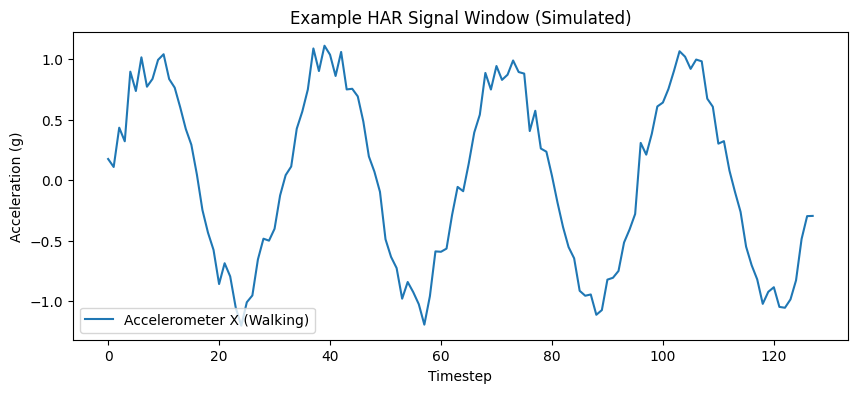

In [2]:
timesteps = np.arange(128)
signal = np.sin(2 * np.pi * timesteps / 32) + 0.1 * np.random.randn(128)

plt.figure(figsize=(10,4))
plt.plot(timesteps, signal, label="Accelerometer X (Walking)")
plt.xlabel("Timestep")
plt.ylabel("Acceleration (g)")
plt.title("Example HAR Signal Window (Simulated)")
plt.legend()
plt.show()

In [3]:
zip_file_path = "/content/drive/MyDrive/UCI HAR Dataset.zip"
extract_dir = "/content"


os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Extracted files to: {extract_dir}")

Extracted files to: /content


In [5]:
BASE_DIR = Path("UCI HAR Dataset")
assert BASE_DIR.exists(), f"BASE_DIR does not exist: {BASE_DIR}"

ACTIVITY_MAP = {
    1: "WALKING",
    2: "WALKING_UPSTAIRS",
    3: "WALKING_DOWNSTAIRS",
    4: "SITTING",
    5: "STANDING",
    6: "LAYING",
}
NUM_CLASSES = 6

In [6]:
SIGNAL_NAMES = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "total_acc_x","total_acc_y","total_acc_z",
    "body_gyro_x","body_gyro_y","body_gyro_z",
]

def load_split(split="train", base_dir=BASE_DIR):
    """
    Returns:
        X: np.ndarray, shape (N, 128, 9)
        y: np.ndarray, shape (N,) with class indices in {0..5}
        subjects: np.ndarray, shape (N,) with subject IDs (1..30)
    """
    sig_dir = base_dir / split / "Inertial Signals"
    matrices = []
    for name in SIGNAL_NAMES:
        fpath = sig_dir / f"{name}_{split}.txt"
        arr = np.loadtxt(fpath, dtype=np.float32)  # shape: (N, 128)
        matrices.append(arr[:, :, None])           # -> (N, 128, 1)

    X = np.concatenate(matrices, axis=2)          # (N, 128, 9)
    y = np.loadtxt(base_dir / split / f"y_{split}.txt", dtype=np.int64)
    y = y - 1  # convert {1..6} -> {0..5}
    subjects = np.loadtxt(base_dir / split / f"subject_{split}.txt", dtype=np.int64)
    return X, y, subjects

X_train_np, y_train_np, subj_train = load_split("train", BASE_DIR)
X_test_np,  y_test_np,  subj_test  = load_split("test",  BASE_DIR)

print("Train X shape:", X_train_np.shape, "(N, 128, 9)")
print("Train y shape:", y_train_np.shape,  "(N,)  class indices in {0..5}")
print("Test  X shape:", X_test_np.shape)
print("Test  y shape:", y_test_np.shape)
print("Unique train labels:", np.unique(y_train_np))

Train X shape: (7352, 128, 9) (N, 128, 9)
Train y shape: (7352,) (N,)  class indices in {0..5}
Test  X shape: (2947, 128, 9)
Test  y shape: (2947,)
Unique train labels: [0 1 2 3 4 5]


In [7]:
EPS = 1e-8

train_mean = X_train_np.mean(axis=(0,1), keepdims=True)  # shape (1,1,9)
# axis(0,1) means "collapse N and T, keep channels" and get mean/std per channel. keepdims=True keeps the 3D shape for broadcasting
# axis=0 would collapse N only, giving (1, 128, 9) mean per timestep
# axis=1 would collapse T only, giving (N, 1, 9) mean per sample
# axis=2 would collapse channels only, giving (N, 128, 1) mean per sample/timestep
# We want (1,1,9) to broadcast correctly when subtracting from (N,128,9)
# So we get one mean/std per channel over the entire TRAIN set

train_std  = X_train_np.std(axis=(0,1),  keepdims=True)  # shape (1,1,9)

X_train_std = (X_train_np - train_mean) / (train_std + EPS)
X_test_std  = (X_test_np  - train_mean) / (train_std + EPS)  # use train stats!

print("Per-channel mean (train):", train_mean.reshape(-1)[:3], "... (showing first 3)")
print("Per-channel std  (train):", train_std.reshape(-1)[:3],  "... (showing first 3)")

Per-channel mean (train): [-0.00063632 -0.0002923  -0.0002753 ] ... (showing first 3)
Per-channel std  (train): [0.19478364 0.12235899 0.10680177] ... (showing first 3)


In [8]:
# Convert to PyTorch tensors

X_train_t = torch.from_numpy(X_train_std)  # (N, 128, 9), float32
y_train_t = torch.from_numpy(y_train_np)   # (N,), int64

X_test_t  = torch.from_numpy(X_test_std)
y_test_t  = torch.from_numpy(y_test_np)

print(X_train_t.shape, y_train_t.shape, X_test_t.shape, y_test_t.shape)

torch.Size([7352, 128, 9]) torch.Size([7352]) torch.Size([2947, 128, 9]) torch.Size([2947])


In [9]:
def preview_sequence(X_np, y_np, index=0, timesteps_to_show=10):
    seq = X_np[index]  # (128, 9)
    label_idx = int(y_np[index])
    label_name = ACTIVITY_MAP[label_idx + 1]
    print(f"Sample index: {index}")
    print(f"Label index/name: {label_idx} / {label_name}")
    print(f"Sequence shape: {seq.shape} (timesteps, features)")
    print("First few timesteps (first 3 features):")
    print(seq[:timesteps_to_show, :3])  # show first 3 channels for brevity

preview_sequence(X_train_std, y_train_np, index=0, timesteps_to_show=8)

Sample index: 0
Label index/name: 4 / STANDING
Sequence shape: (128, 9) (timesteps, features)
First few timesteps (first 3 features):
[[0.00419526 0.09038245 0.5228001 ]
 [0.05531714 0.05616078 0.5187192 ]
 [0.05088666 0.07536164 0.45579797]
 [0.0292746  0.06359139 0.46862772]
 [0.05876554 0.05257694 0.40531576]
 [0.02403393 0.05914247 0.42138427]
 [0.02769068 0.03142163 0.41192463]
 [0.03516703 0.02312396 0.33383194]]


Example indices -> WALKING: 78  SITTING: 27


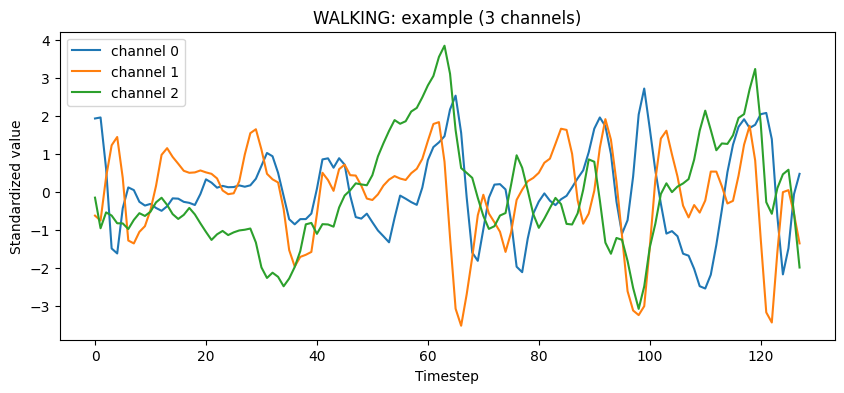

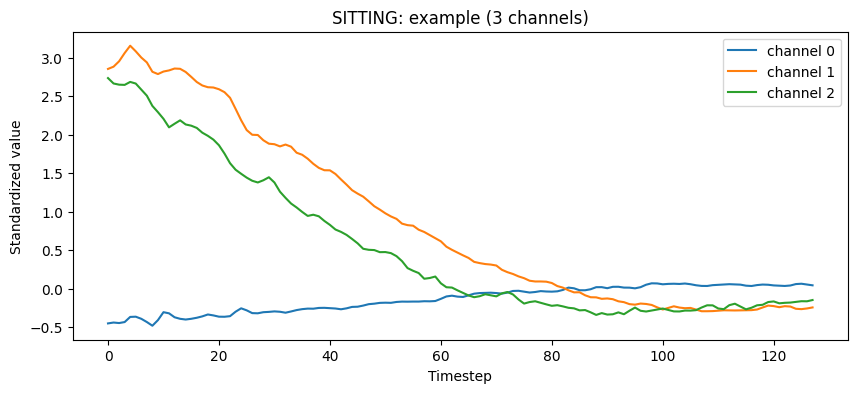

In [10]:
def find_first_index(y_np, class_index):
    idxs = np.where(y_np == class_index)[0]
    return int(idxs[0]) if len(idxs) > 0 else None

idx_walk   = find_first_index(y_train_np, 0)  # WALKING -> 1 -> index 0
idx_sit    = find_first_index(y_train_np, 3)  # SITTING -> 4 -> index 3

print("Example indices -> WALKING:", idx_walk, " SITTING:", idx_sit)

def plot_three_channels(seq, title, channels=(0,1,2)):
    t = np.arange(seq.shape[0])  # 0..127
    plt.figure(figsize=(10,4))
    for c in channels:
        plt.plot(t, seq[:, c], label=f"channel {c}")
    plt.xlabel("Timestep")
    plt.ylabel("Standardized value")
    plt.title(title)
    plt.legend()
    plt.show()

if idx_walk is not None:
    plot_three_channels(X_train_std[idx_walk], "WALKING: example (3 channels)")

if idx_sit is not None:
    plot_three_channels(X_train_std[idx_sit], "SITTING: example (3 channels)")

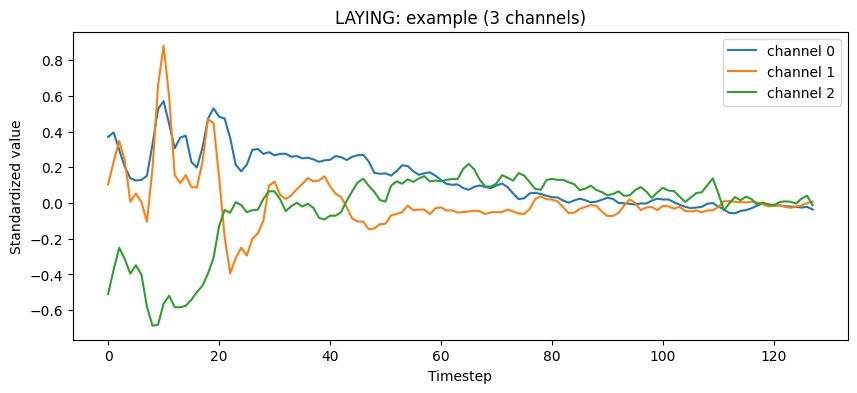

In [11]:
def CT_find_first_index(y_np, class_index):
    idxs = np.where(y_np == class_index)[0]
    return int(idxs[0]) if len(idxs) > 0 else None

CT_idx_laying = CT_find_first_index(y_train_np, 5)

# Pull standardized sequence (128, 9)
CT_seq_laying = X_train_std[CT_idx_laying]   # expect X_train_std

# Channels to show
CT_channels = (0, 1, 2)

# Plot
t = np.arange(CT_seq_laying.shape[0])
plt.figure(figsize=(10,4))
for c in CT_channels:
    plt.plot(t, CT_seq_laying[:, c], label=f"channel {c}")
plt.xlabel("Timestep")
plt.ylabel("Standardized value")
plt.title("LAYING: example (3 channels)")
plt.legend()
plt.show()

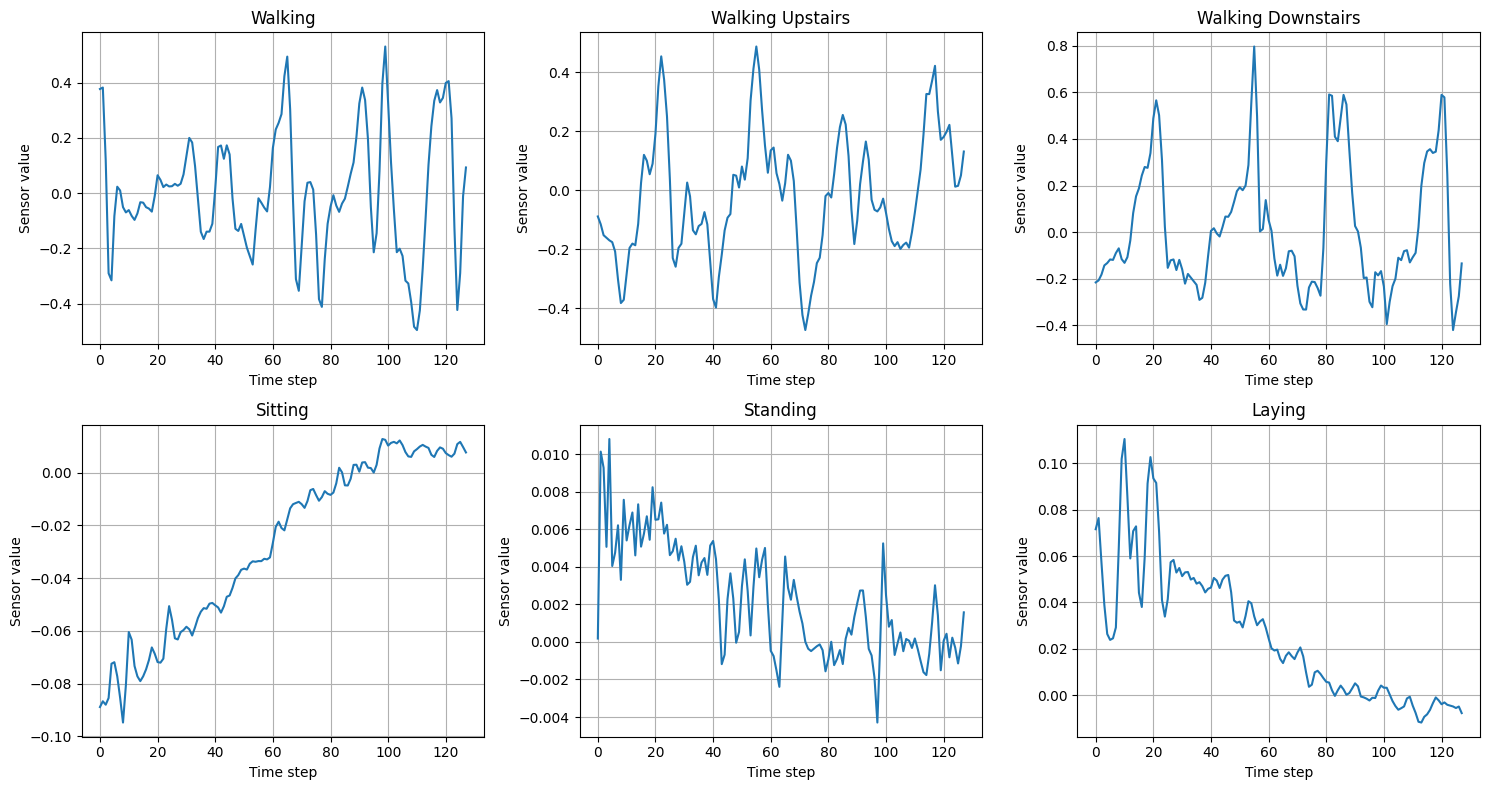

In [17]:
activity_names = [
    "Walking",
    "Walking Upstairs",
    "Walking Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for activity_id, ax in enumerate(axes.flat):

    indices = np.where(y_train_np == activity_id)[0]

    sample = X_train_np[indices[0]]

    ax.plot(sample[:, 0])

    ax.set_title(activity_names[activity_id])
    ax.set_xlabel("Time step")
    ax.set_ylabel("Sensor value")
    ax.grid(True)

plt.tight_layout()
plt.show()

---

# Case 1 – Minimal RNN (batch=1, hidden_size=1)

**Why start simple?**

Before we scale up, let’s build intuition with the **simplest possible RNN**:

- **Batch size = 1**  
  → we only look at **one sequence** at a time.  
  → No parallelization, easier to “follow the story” of the hidden state.

- **Hidden size = 1**  
  → the hidden state is just a **single number**.  
  → Think of it as a tiny memory slot that gets updated at each timestep.  

This makes it very clear what happens at each step.

**The RNN equations (scalar case)**

At timestep $t$:

$$
h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)
$$

- $x_t$: input at timestep $t$ (a 9-dimensional vector).  
- $h_{t-1}$: the hidden state carried from the previous timestep (a scalar here).  
- $h_t$: the updated hidden state (still a scalar).  

At the end of the sequence ($t=128$), we use the last hidden state to make a prediction:

$$
\hat{y} = \text{softmax}(W_{hy} h_{128} + b_y)
$$

**Intuition**

- The RNN is like a **rolling summary** of everything seen so far.  
- At each timestep, the hidden state **compresses the past + current input** into one value.  
- By the end of 128 steps, the last hidden state $h_{128}$ represents the whole sequence.  

In [19]:
seq = X_train_t[0]       # shape (128, 9)
label = y_train_t[0].item()

print("Sequence shape:", seq.shape, "(timesteps=128, features=9)")
print("Label index:", label, "->", ACTIVITY_MAP[label+1])

# Reshape to (seq_len, batch, input_size)
seq_in = seq.unsqueeze(1)  # (128, 1, 9)
print("Input to RNN shape:", seq_in.shape)

Sequence shape: torch.Size([128, 9]) (timesteps=128, features=9)
Label index: 4 -> STANDING
Input to RNN shape: torch.Size([128, 1, 9])


In [20]:
rnn = nn.RNN(input_size=9, hidden_size=1, batch_first=False)

# Forward pass
out_seq, h_n = rnn(seq_in)   # out_seq: (128, 1, 1), h_n: (1, 1, 1)

# Classification head: hidden -> 6 classes
fc = nn.Linear(1, NUM_CLASSES)
logits = fc(h_n.squeeze(0))   # shape (1,6)
probs = F.softmax(logits, dim=1)

print("out_seq shape:", out_seq.shape, "(seq_len=128, batch=1, hidden=1)")
print("h_n shape:", h_n.shape, "(num_layers=1, batch=1, hidden=1)")
print("logits shape:", logits.shape, "(1,6)")
print("probs shape:", probs.shape, "(1,6)")
print("probs sum:", probs.sum().item())

out_seq shape: torch.Size([128, 1, 1]) (seq_len=128, batch=1, hidden=1)
h_n shape: torch.Size([1, 1, 1]) (num_layers=1, batch=1, hidden=1)
logits shape: torch.Size([1, 6]) (1,6)
probs shape: torch.Size([1, 6]) (1,6)
probs sum: 1.0


In [21]:
print("First 5 hidden states (scalars):", out_seq[:5,0,0].detach().numpy())
print("Last hidden state:", h_n[0,0,0].item())

First 5 hidden states (scalars): [0.01604045 0.14037701 0.08392028 0.07597879 0.12802252]
Last hidden state: -0.030303342267870903


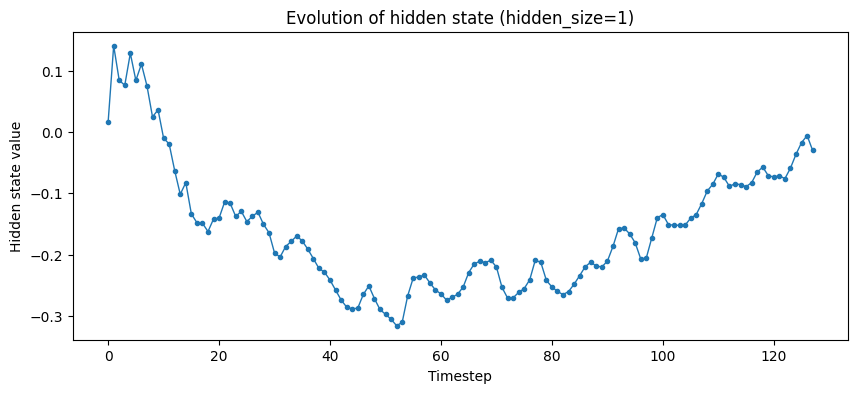

In [22]:
h_values = out_seq[:,0,0].detach().numpy()  # shape (128,)

plt.figure(figsize=(10,4))
plt.plot(range(128), h_values, marker='o', markersize=3, linewidth=1)
plt.xlabel("Timestep")
plt.ylabel("Hidden state value")
plt.title("Evolution of hidden state (hidden_size=1)")
plt.show()

# **Case 2 – Small Hidden Vector (batch=1, hidden_size=3)**

**Why increase hidden size?**

- With **hidden_size=1**, the RNN’s memory is just a single number → very limited capacity.  
- By increasing to **hidden_size=3**, the RNN now has a **3-dimensional hidden vector** at each timestep.  
- This gives the model **more capacity** to store and process different aspects of the temporal signal.  

Think of it as moving from:
- A notepad with **1 column** → only one number at a time.  
- To a notepad with **3 columns** → we can track multiple patterns simultaneously.  

**The RNN equations (vector case)**

At timestep $t$:

$$
h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)
$$

- Now $h_t \in \mathbb{R}^3$ (instead of $\mathbb{R}^1$).  
- Each of the 3 hidden units can learn to detect **different temporal patterns** in the signal.  

At the end:

$$
\hat{y} = \text{softmax}(W_{hy} h_{128} + b_y), \quad h_{128} \in \mathbb{R}^3
$$

**What we will do**

1. Reuse the same sequence from Case 1.  
2. Run it through an RNN with `hidden_size=3`.  
3. Print:  
   - shapes of `out_seq` and `h_n`  
   - a sample of hidden states across time  
   - the logits and softmax probabilities.  
4. Plot the **3 hidden dimensions** across 128 timesteps.

In [23]:
rnn2 = nn.RNN(input_size=9, hidden_size=3, batch_first=False)

# Forward pass on same sequence
out_seq2, h_n2 = rnn2(seq_in)   # out_seq2: (128, 1, 3), h_n2: (1, 1, 3)

# Classification head: hidden -> 6 classes
fc2 = nn.Linear(3, NUM_CLASSES)
logits2 = fc2(h_n2.squeeze(0))   # shape (1,6)
probs2 = F.softmax(logits2, dim=1)

print("out_seq2 shape:", out_seq2.shape, "(seq_len=128, batch=1, hidden=3)")
print("h_n2 shape:", h_n2.shape, "(num_layers=1, batch=1, hidden=3)")
print("logits2 shape:", logits2.shape, "(1,6)")
print("probs2 shape:", probs2.shape, "(1,6)")

out_seq2 shape: torch.Size([128, 1, 3]) (seq_len=128, batch=1, hidden=3)
h_n2 shape: torch.Size([1, 1, 3]) (num_layers=1, batch=1, hidden=3)
logits2 shape: torch.Size([1, 6]) (1,6)
probs2 shape: torch.Size([1, 6]) (1,6)


In [24]:
print("First hidden state (3-dim):", out_seq2[0,0,:].detach().numpy())
print("Last hidden state (3-dim):", h_n2[0,0,:].detach().numpy())

First hidden state (3-dim): [-0.78947246  0.4140645  -0.28335303]
Last hidden state (3-dim): [-0.8007568   0.27731815 -0.49507132]


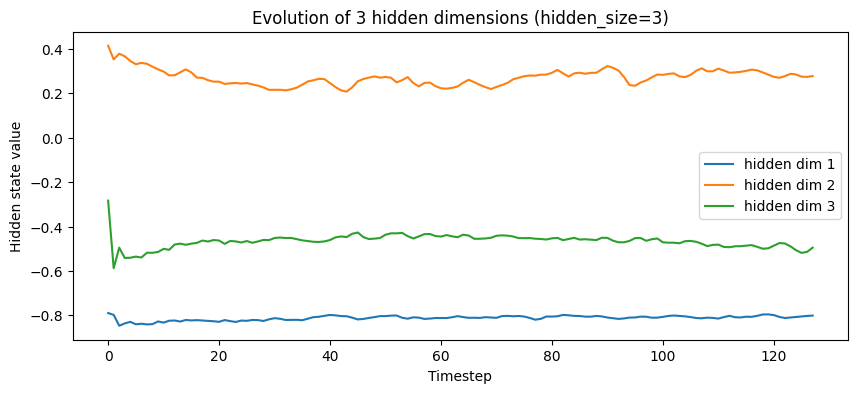

In [25]:
h_values2 = out_seq2[:,0,:].detach().numpy()  # shape (128,3)

plt.figure(figsize=(10,4))
for dim in range(3):
    plt.plot(range(128), h_values2[:,dim], label=f"hidden dim {dim+1}")
plt.xlabel("Timestep")
plt.ylabel("Hidden state value")
plt.title("Evolution of 3 hidden dimensions (hidden_size=3)")
plt.legend()
plt.show()

---

# **Case 3 – Realistic Batch (batch=32, hidden_size=32)**

**Why scale up?**

- So far, we used **batch=1** → easy to follow step by step, but not practical.  
- In training, we want to process **many sequences in parallel** to speed things up → **batch size > 1**.  
- Also, we want a hidden state with enough capacity to capture complex patterns → **hidden_size > 1**.  
- Here we’ll try `batch_size=32`, `hidden_size=32`.

**Time-first vs batch-first**

RNNs in PyTorch expect inputs in one of two formats:

- **Time-first (default):**  
  $(\text{seq\_len}, \text{batch}, \text{input\_size})$  
  Example: $(128, 32, 9)$  
  → At timestep 1, the RNN processes *all 32 sequences* in parallel.  

- **Batch-first (optional):**  
  $(\text{batch}, \text{seq\_len}, \text{input\_size})$  
  Example: $(32, 128, 9)$  
  → More intuitive (batch dimension comes first).  

We can choose either:
- Use **time-first** (default) and call `.permute(1,0,2)` to swap axes.  
- Or create the RNN with `batch_first=True`.  

**Intuition**

- In **time-first**, we conceptually “march through time” one step at a time, updating all sequences in the batch together.  
- In **batch-first**, we conceptually “line up full sequences” for each sample, then let the RNN handle the time loop internally.  
- Both are equivalent — it’s just about how we arrange the input tensor.

**What we will do**

1. Take a mini-batch of 32 sequences.  
2. Run them through an RNN with `hidden_size=32`.  
3. Print shapes:  
   - `out_seq` → all hidden states over time.  
   - `h_n` → final hidden state for each sequence.  
   - `logits` and `probs` → predictions.  
4. Inspect the first few predicted probability distributions.

In [26]:
batch_size = 32
X_batch = X_train_t[:batch_size]   # (32, 128, 9)
y_batch = y_train_t[:batch_size]   # (32,)

print("Batch shape (batch-first):", X_batch.shape)

# Convert to time-first for default RNN
X_batch_tf = X_batch.permute(1, 0, 2)   # (128, 32, 9)
print("Time-first shape:", X_batch_tf.shape)

Batch shape (batch-first): torch.Size([32, 128, 9])
Time-first shape: torch.Size([128, 32, 9])


In [27]:
# Define RNN with hidden_size=32
rnn3 = nn.RNN(input_size=9, hidden_size=32, batch_first=False)

# Forward pass
out_seq3, h_n3 = rnn3(X_batch_tf)   # out_seq3: (128, 32, 32), h_n3: (1, 32, 32)

# Classification head
fc3 = nn.Linear(32, NUM_CLASSES)
logits3 = fc3(h_n3.squeeze(0))   # (32,6)
probs3 = F.softmax(logits3, dim=1)

print("out_seq3 shape:", out_seq3.shape, "(seq_len=128, batch=32, hidden=32)")
print("h_n3 shape:", h_n3.shape, "(layers=1, batch=32, hidden=32)")
print("logits3 shape:", logits3.shape, "(batch=32, classes=6)")
print("probs3 sum per row (first):", probs3[0].sum().item())

out_seq3 shape: torch.Size([128, 32, 32]) (seq_len=128, batch=32, hidden=32)
h_n3 shape: torch.Size([1, 32, 32]) (layers=1, batch=32, hidden=32)
logits3 shape: torch.Size([32, 6]) (batch=32, classes=6)
probs3 sum per row (first): 0.9999999403953552


In [28]:
for i in range(3):
    probs_row = probs3[i].detach().numpy()
    pred_idx = int(probs_row.argmax())
    print(f"Sample {i}: true={ACTIVITY_MAP[int(y_batch[i])+1]}, "
          f"pred={ACTIVITY_MAP[pred_idx+1]}, "
          f"probs={np.round(probs_row,3)}")

Sample 0: true=STANDING, pred=STANDING, probs=[0.159 0.157 0.174 0.162 0.217 0.132]
Sample 1: true=STANDING, pred=STANDING, probs=[0.154 0.162 0.172 0.162 0.217 0.132]
Sample 2: true=STANDING, pred=STANDING, probs=[0.154 0.161 0.173 0.163 0.217 0.132]


**Reflection**

- **Shapes:**  
  - `out_seq3`: all hidden states across 128 timesteps, for each sequence in the batch.  
  - `h_n3`: just the **last hidden state** for each sequence, used for classification.  
  - `logits3`: classifier outputs for all 32 sequences.  

- **Parallelization:** The RNN processed 32 sequences simultaneously.  
- **Hidden size:** With 32 dimensions, the hidden state can now capture richer, more nuanced temporal features.  
- **Predictions:** We saw softmax probabilities for each activity; the highest probability gives the predicted label.  

---

# Hidden States vs Predictions in RNNs

## 1. RNN Hidden States

An RNN produces a **hidden state** \(h_t\) at every timestep.

For a sequence of 128 timesteps:

$$
x_1, x_2, \ldots, x_{128}
$$

the RNN produces:

$$
h_1, h_2, \ldots, h_{128}
$$

The basic flow is:

```text
x₁ → RNN → h₁
x₂ → RNN → h₂
x₃ → RNN → h₃
 ⋮
x₁₂₈ → RNN → h₁₂₈
```

Therefore, the RNN produces a hidden-state sequence, not just one hidden state.

---

## 2. Hidden State vs Prediction

The **hidden state** is an internal representation produced by the RNN.

A **prediction** is produced when we pass a hidden state through an output/classification layer.

$$
h_t \rightarrow \text{Linear Layer} \rightarrow \text{Logits} \rightarrow \text{Softmax}
$$

Therefore:

> **The RNN produces hidden states; the output layer turns selected hidden states into predictions.**

We do not necessarily need to make a prediction from every hidden state.

---

# 3. Sequence Classification

### Example: UCI HAR

The UCI HAR dataset divides sensor data into windows of:

$$
128 \text{ timesteps} \times 9 \text{ features}
$$

Each window has **one activity label**.

For example:

```text
128 timesteps × 9 sensor features
              ↓
             RNN
              ↓
h₁, h₂, h₃, ..., h₁₂₈
              ↓
         take h₁₂₈
              ↓
        Linear Layer
              ↓
        6 class logits
              ↓
           Softmax
              ↓
      1 activity prediction
```

The final hidden state is:

$$
h_{128}
$$

The prediction is:

$$
\hat{y}
=
\text{softmax}(W_{hy}h_{128}+b_y)
$$

### Shape example

For a batch of 6 sequences with `hidden_size = 6`:

```text
RNN output:
(128, 6, 6)
 │    │  │
 │    │  └── hidden features
 │    └───── batch
 └────────── time
```

The final hidden state:

```text
(1, 6, 6)
```

After removing the RNN layer dimension:

```text
(6, 6)
```

Then the linear classifier produces:

```text
(6, 6)
```

Meaning:

> **6 sequences → 6 predictions, one prediction per sequence.**

---

# 4. Sequence Labeling

Sequence labeling is different.

Instead of one label for the entire sequence, we want **one label at every timestep**.

For example:

```text
h₁   → prediction 1
h₂   → prediction 2
h₃   → prediction 3
...
h₁₂₈ → prediction 128
```

Formally:

$$
\hat{y}_t
=
\text{softmax}(W_{hy}h_t+b_y)
$$

for:

$$
t=1,\ldots,128
$$

The flow is:

```text
x₁ → RNN → h₁ → Linear → ŷ₁
x₂ → RNN → h₂ → Linear → ŷ₂
x₃ → RNN → h₃ → Linear → ŷ₃
 ⋮
x₁₂₈ → RNN → h₁₂₈ → Linear → ŷ₁₂₈
```

---

# 5. Classification vs Labeling

| Task                        | Hidden states used     | Predictions      |
| --------------------------- | ---------------------- | ---------------- |
| **Sequence classification** | Usually final \(h_T\)  | One per sequence |
| **Sequence labeling**       | All \(h_1,\ldots,h_T\) | One per timestep |

### Sequence classification

$$
h_1,h_2,\ldots,h_{128}
\rightarrow
h_{128}
\rightarrow
\hat{y}
$$

**128 timesteps → 1 label**

### Sequence labeling

$$
h_1,h_2,\ldots,h_{128}
\rightarrow
\hat{y}_1,\hat{y}_2,\ldots,\hat{y}_{128}
$$

**128 timesteps → 128 labels**

---

# 6. Why HAR Uses Sequence Classification

For UCI HAR, each 128-timestep window represents an activity such as:

* Walking
* Walking Upstairs
* Walking Downstairs
* Sitting
* Standing
* Laying

The dataset assigns **one activity label to the whole window**.

Therefore:

$$
128 \text{ timesteps} \rightarrow 1 \text{ activity label}
$$

This makes **sequence classification** appropriate.

If the dataset instead provided a label for every individual timestep, then sequence labeling would be appropriate.

---

# 7. Important Distinction

The RNN always generates:

$$
h_1,h_2,\ldots,h_T
$$

But **we decide how to use them**.

### Classification

```text
RNN
 ↓
h₁ h₂ h₃ ... hₜ
             ↓
          use hₜ
             ↓
        classifier
             ↓
          one label
```

### Labeling

```text
RNN
 ↓
h₁ h₂ h₃ ... hₜ
 ↓  ↓  ↓      ↓
classifier at every timestep
 ↓  ↓  ↓      ↓
ŷ₁ ŷ₂ ŷ₃ ... ŷₜ
```

> **The hidden states are representations. Predictions are produced by the classifier using those representations.**


# RNNs and UCI HAR — Learned Principles

## 1. Understanding the UCI HAR Data

The UCI Human Activity Recognition (HAR) dataset contains sensor measurements collected from smartphones while people performed different physical activities.

The raw sequential data can be represented as:

```text
(batch, time, features)
```

For this dataset:

```text
(batch, 128, 9)
```

### Meaning of the dimensions

* **Batch** → number of sequences processed together
* **128** → number of timesteps in each sequence
* **9** → sensor features/channels at each timestep

Therefore, one sequence has:

```text
128 timesteps × 9 features
```

The 128 measurements represent a short time window of sensor activity.

---

# 2. Sequence Data Is Different From Ordinary Tabular Data

A normal tabular dataset might look like:

```text
(samples, features)
```

For example:

```text
(1000, 20)
```

An RNN deals with an additional **time dimension**:

```text
(samples, timesteps, features)
```

For HAR:

```text
(N, 128, 9)
```

The important principle is:

> **An RNN needs to know both what the features are and how they are ordered through time.**

The order of observations matters.

---

# 3. The Three Important Dimensions

For an RNN input, always identify:

```text
T = sequence length / timesteps
B = batch size
F = number of features
```

For example:

```text
T = 128
B = 6
F = 9
```

Therefore, the same data can be represented as either:

```text
(B, T, F)
= (6, 128, 9)
```

or:

```text
(T, B, F)
= (128, 6, 9)
```

The data itself has not changed. Only the **order of the dimensions** has changed.

---

# 4. Batch Size

A batch contains multiple sequences processed simultaneously.

For example:

```python
CT_batch6 = X_train_t[:6]
```

If the original data is:

```text
(N, 128, 9)
```

then selecting six sequences gives:

```text
(6, 128, 9)
```

This means:

```text
6 sequences
× 128 timesteps
× 9 features
```

Batching allows the RNN to process multiple independent sequences at the same time.

---

# 5. Why Tensor Dimensions Sometimes Need to Be Converted

PyTorch's `nn.RNN` traditionally expects:

```text
(sequence_length, batch_size, input_size)
```

when:

```python
batch_first=False
```

Therefore, if our data is:

```text
(B, T, F)
```

we need:

```text
(T, B, F)
```

For example:

```python
CT_batch6_tf = CT_batch6.permute(1, 0, 2)
```

This changes:

```text
(6, 128, 9)
```

into:

```text
(128, 6, 9)
```

### Important principle

`permute()` does **not** change the underlying values.

It changes the order in which the dimensions are interpreted.

---

# 6. `permute(1, 0, 2)`

If a tensor has:

```text
(B, T, F)
```

then:

```python
x.permute(1, 0, 2)
```

produces:

```text
(T, B, F)
```

The dimension mapping is:

```text
old dimension 0 → new dimension 1
old dimension 1 → new dimension 0
old dimension 2 → new dimension 2
```

So:

```text
(B, T, F)
      ↓
(T, B, F)
```

The reverse operation is also:

```python
x.permute(1, 0, 2)
```

because swapping the first two dimensions twice returns the original arrangement.

---

# 7. `batch_first=True` Is an Alternative

We do not mathematically need to convert the data.

Instead, we can configure the RNN to accept:

```text
(B, T, F)
```

directly:

```python
rnn = nn.RNN(
    input_size=9,
    hidden_size=6,
    batch_first=True
)
```

Then:

```text
Input:
(6, 128, 9)

Output:
(6, 128, 6)
```

This can be more intuitive because many datasets naturally use:

```text
(batch, time, features)
```

### Key principle

> **The dimension convention is an interface requirement, not a mathematical requirement of RNNs.**

---

# 8. What an RNN Actually Produces

An RNN processes a sequence one timestep at a time.

Conceptually:

```text
x₁ → h₁
x₂ → h₂
x₃ → h₃
...
x₁₂₈ → h₁₂₈
```

Each hidden state contains information about the sequence processed up to that point.

Therefore, an RNN produces:

```text
h₁, h₂, h₃, ..., h₁₂₈
```

These are called **hidden states**.

---

# 9. Hidden Size

The hidden size determines how many values are contained in each hidden state.

For:

```python
hidden_size = 6
```

each hidden state has six values:

```text
h_t ∈ R⁶
```

Therefore, for 128 timesteps:

```text
128 × 6
```

hidden values are produced for each sequence.

For a batch of six:

```text
128 × 6 × 6
```

or:

```text
(T, B, H)
```

where:

```text
T = 128
B = 6
H = 6
```

---

# 10. RNN Output Tensor vs Final Hidden State

This is one of the most important distinctions.

PyTorch's RNN returns:

```python
output, hidden = rnn(x)
```

### `output`

Contains the hidden state at **every timestep**.

For:

```text
T = 128
B = 6
H = 6
```

we get:

```text
output.shape
= (128, 6, 6)
```

Conceptually:

```text
output =
[
    h₁,
    h₂,
    h₃,
    ...
    h₁₂₈
]
```

### `hidden`

Contains the final hidden state for each recurrent layer.

For one RNN layer:

```text
hidden.shape
= (1, 6, 6)
```

The dimensions are:

```text
(num_layers, batch, hidden_size)
```

So:

```text
(1, 6, 6)
```

means:

```text
1 RNN layer
6 sequences
6 hidden values
```

---

# 11. Why `squeeze(0)` Is Used

For sequence classification, we usually want:

```text
(batch, hidden_size)
```

instead of:

```text
(num_layers, batch, hidden_size)
```

Therefore:

```python
CT_last_hidden_b6 = CT_hn_b6.squeeze(0)
```

changes:

```text
(1, 6, 6)
```

into:

```text
(6, 6)
```

The first dimension disappears because there is only one RNN layer.

---

# 12. Hidden State Is Not the Prediction

A hidden state is an internal representation created by the RNN.

It is **not automatically the final class prediction**.

The process is:

```text
Input sequence
      ↓
RNN
      ↓
Hidden state
      ↓
Linear classifier
      ↓
Logits
      ↓
Softmax
      ↓
Class probabilities
```

Therefore:

> **The RNN creates representations; the classifier converts those representations into predictions.**

---

# 13. The Linear Layer

Suppose:

```python
hidden_size = 6
NUM_CLASSES = 6
```

Then:

```python
nn.Linear(6, 6)
```

maps:

```text
6 hidden values
      ↓
6 class scores
```

For a batch:

```text
(6, 6)
      ↓
Linear
      ↓
(6, 6)
```

The first dimension is still the batch size.

The second dimension represents the six classes.

---

# 14. Logits

The output of the linear layer is called **logits**.

For example:

```python
logits = fc(hidden)
```

The logits are raw class scores.

They are not probabilities yet.

Example conceptually:

```text
[-1.2, 0.7, 3.1, -0.4, 0.8, 1.2]
```

The largest value indicates the class with the strongest score before probability normalization.

---

# 15. Softmax

Softmax converts logits into probabilities.

Conceptually:

```text
logits
   ↓
softmax
   ↓
probabilities
```

The probabilities:

* are between 0 and 1
* sum to approximately 1

For example:

```text
[0.02, 0.10, 0.65, 0.04, 0.08, 0.11]
```

The model would assign the highest probability to class 3.

The mathematical expression is:

```text
P(y=i) = exp(zᵢ) / Σ exp(zⱼ)
```

---

# 16. Sequence Classification

Sequence classification means:

> **One entire sequence receives one label.**

This is appropriate for the UCI HAR task.

The input is:

```text
128 timesteps × 9 features
```

The output is:

```text
1 activity label
```

For a batch of six:

```text
6 sequences
      ↓
6 predictions
```

---

# 17. Sequence Classification Using the Final Hidden State

For sequence classification, we can use the final hidden state:

```text
h₁₂₈
```

The complete process is:

```text
x₁ ... x₁₂₈
      ↓
     RNN
      ↓
h₁ ... h₁₂₈
      ↓
   h₁₂₈
      ↓
Linear layer
      ↓
6 logits
      ↓
Softmax
      ↓
1 activity prediction
```

Mathematically:

```text
ŷ = softmax(W_hy h₁₂₈ + b_y)
```

---

# 18. Sequence Classification Shapes

For batch size 6 and hidden size 6:

### Input

```text
(128, 6, 9)
```

### RNN output

```text
(128, 6, 6)
```

### Final hidden state

```text
(1, 6, 6)
```

### After `squeeze(0)`

```text
(6, 6)
```

### After classifier

```text
(6, 6)
```

### After softmax

```text
(6, 6)
```

The final shape means:

```text
6 sequences × 6 class probabilities
```

---

# 19. Sequence Labeling

Sequence labeling is different.

Instead of predicting one label for the entire sequence, we predict a label at **every timestep**.

Conceptually:

```text
x₁ → h₁ → prediction₁
x₂ → h₂ → prediction₂
x₃ → h₃ → prediction₃
...
x₁₂₈ → h₁₂₈ → prediction₁₂₈
```

Therefore:

```text
128 hidden states
      ↓
128 predictions
```

for each sequence.

---

# 20. Sequence Labeling Formula

For every timestep:

```text
ŷ_t = softmax(W_hy h_t + b_y)
```

where:

```text
t = 1, 2, ..., 128
```

Unlike sequence classification, we do not throw away the intermediate hidden states.

We use:

```text
h₁, h₂, ..., h₁₂₈
```

---

# 21. Flattening Hidden States for Classification

Suppose:

```text
CT_out_seq_b6.shape
= (128, 6, 6)
```

This contains:

```text
128 timesteps
× 6 sequences
× 6 hidden values
```

To apply a linear layer to every hidden state, we can flatten the first two dimensions:

```python
CT_out_seq_flat_b6 = CT_out_seq_b6.reshape(-1, 6)
```

This produces:

```text
(768, 6)
```

because:

```text
128 × 6 = 768
```

Then:

```python
CT_logits_lbl_b6 = CT_fc_b6_h6(CT_out_seq_flat_b6)
```

produces:

```text
(768, 6)
```

Each of the 768 rows represents one timestep from one sequence.

---

# 22. Classification vs Labeling

| Property                | Sequence Classification    | Sequence Labeling          |
| ----------------------- | -------------------------- | -------------------------- |
| Predictions             | One per sequence           | One per timestep           |
| Hidden states used      | Usually final hidden state | All hidden states          |
| HAR example             | Activity for a window      | Activity at every timestep |
| Input                   | 128 × 9                    | 128 × 9                    |
| Output for one sequence | 1 label                    | 128 labels                 |
| Main representation     | `h₁₂₈`                     | `h₁ ... h₁₂₈`              |

---

# 23. Why UCI HAR Uses Sequence Classification

The HAR dataset assigns one activity label to each window.

For example:

```text
128 sensor measurements
        ↓
One activity
```

Possible classes include:

```text
Walking
Walking Upstairs
Walking Downstairs
Sitting
Standing
Laying
```

Therefore, the natural task is:

```text
sequence → one class
```

rather than:

```text
sequence → 128 classes
```

If we wanted a label for every individual timestep, we would need appropriately labeled timestep-level data.

---

# 24. Understanding `unsqueeze`

Sometimes a single sequence does not have a batch dimension.

For example:

```text
(128, 9)
```

means:

```text
128 timesteps
9 features
```

But the RNN expects a batch dimension.

We can add one with:

```python
x.unsqueeze(1)
```

giving:

```text
(128, 1, 9)
```

Now:

```text
T = 128
B = 1
F = 9
```

So the sequence is treated as a batch containing one example.

---

# 25. Understanding `reshape`

`reshape()` changes the arrangement of elements into a new shape while preserving the total number of elements.

For:

```text
(128, 6, 6)
```

the number of elements is:

```text
128 × 6 × 6 = 4608
```

After:

```python
reshape(-1, 6)
```

we get:

```text
(768, 6)
```

because:

```text
768 × 6 = 4608
```

The `-1` tells PyTorch to calculate that dimension automatically.

---

# 26. Reading Tensor Shapes Systematically

When looking at an RNN tensor, do not memorize shapes blindly.

Instead ask:

### Step 1 — What does each dimension represent?

For example:

```text
(T, B, F)
```

### Step 2 — What are the values?

```text
T = 128
B = 6
F = 9
```

### Step 3 — What does the RNN add?

The RNN replaces the input feature dimension with the hidden dimension:

```text
(T, B, F)
      ↓
RNN
      ↓
(T, B, H)
```

Therefore:

```text
(128, 6, 9)
      ↓
(128, 6, 6)
```

if:

```text
H = 6
```

---

# 27. A Useful General RNN Shape Rule

For:

```python
nn.RNN(
    input_size=F,
    hidden_size=H,
    batch_first=False
)
```

the input is:

```text
(T, B, F)
```

and the output is:

```text
(T, B, H)
```

The hidden state is:

```text
(num_layers, B, H)
```

For one layer:

```text
(1, B, H)
```

---

# 28. The Most Important Mental Model

Think of the RNN as a machine that reads a sequence:

```text
x₁ → x₂ → x₃ → ... → x_T
```

and continuously updates its memory:

```text
h₁ → h₂ → h₃ → ... → h_T
```

The hidden state summarizes information from the sequence processed so far.

Then the task determines what happens next.

### Classification

```text
h_T → classifier → one prediction
```

### Labeling

```text
h₁ → classifier → prediction₁
h₂ → classifier → prediction₂
...
h_T → classifier → prediction_T
```

This distinction is more important than memorizing individual code lines.

---

# 29. Common Errors and What They Mean

## `IndexError: index 0 is out of bounds`

If:

```python
indices = np.where(y_train == activity_id)[0]
```

produces an empty array, then:

```python
indices[0]
```

does not exist.

This usually means the requested `activity_id` does not occur in `y_train`.

Check:

```python
np.unique(y_train)
```

before assuming the labels use the values you expect.

---

# 30. Debugging Principle: Inspect Before Assuming

When a tensor or label operation fails, inspect:

```python
print(X_train.shape)
print(y_train.shape)
print(np.unique(y_train))
```

For tensors:

```python
print(x.shape)
print(output.shape)
print(hidden.shape)
```

A shape error often becomes obvious once the actual tensor dimensions are displayed.

---

# 31. Core Principles to Remember

### Principle 1

> **Sequence data has a time dimension.**

```text
(B, T, F)
```

is different from ordinary tabular:

```text
(B, F)
```

### Principle 2

> **Batching processes multiple independent sequences simultaneously.**

### Principle 3

> **`permute()` changes dimension order, not the underlying information.**

### Principle 4

> **`batch_first=True` lets an RNN use `(B, T, F)` directly.**

### Principle 5

> **The hidden size determines the size of the RNN's internal representation.**

### Principle 6

> **`output` contains hidden states from all timesteps.**

### Principle 7

> **`hidden` contains the final hidden state for each recurrent layer.**

### Principle 8

> **A hidden state is a representation, not a prediction.**

### Principle 9

> **A linear layer converts hidden representations into logits.**

### Principle 10

> **Softmax converts logits into class probabilities.**

### Principle 11

> **Sequence classification produces one prediction per sequence.**

### Principle 12

> **Sequence labeling produces one prediction per timestep.**

### Principle 13

> **For sequence classification, the final hidden state is often used as the sequence representation.**

### Principle 14

> **For sequence labeling, the hidden state at every timestep is used.**

### Principle 15

> **Always interpret tensor shapes semantically instead of memorizing them.**

---

# 32. The Entire HAR RNN Pipeline

The complete mental picture is:

```text
UCI HAR sensor data
        ↓
(B, 128, 9)
        ↓
Rearrange if necessary
        ↓
(128, B, 9)
        ↓
       RNN
        ↓
(128, B, H)
        ↓
Final hidden state
        ↓
(1, B, H)
        ↓
squeeze(0)
        ↓
(B, H)
        ↓
Linear layer
        ↓
(B, 6)
        ↓
Softmax
        ↓
(B, 6) probabilities
        ↓
Predicted activity
```

For sequence labeling, the middle changes:

```text
(128, B, H)
        ↓
All hidden states
        ↓
reshape
        ↓
(128 × B, H)
        ↓
Linear
        ↓
(128 × B, 6)
        ↓
One prediction for every timestep
```

---

# 33. Final Mental Model

The most useful way to remember the whole session is:

```text
DATA
(B, T, F)
   ↓
RNN
   ↓
HIDDEN STATES
(T, B, H)
   ↓
choose how to use them
   ├── final hidden state → sequence classification
   │                         ↓
   │                      one label
   │
   └── all hidden states → sequence labeling
                             ↓
                         one label/timestep
```

The fundamental idea is:

> **An RNN transforms a sequence of feature vectors into a sequence of hidden representations. The downstream task determines which hidden representations are converted into predictions.**
